# Hierarchical Gaussian fit

Here I demonstrate how to fit a Gaussian hierarchically in _pyMC_. We use a KDE to smoothen over samples.

In [1]:
%matplotlib inline

In [8]:
import pymc as pm
import numpy as np
import pytensor.tensor as pt
import arviz as az

In [100]:
def make_model(x_samples_stack, manual=False):
    with pm.Model() as model:
        Nobs = x_samples_stack.shape[0]
        Nsamp = x_samples_stack.shape[1]

        # hyper prior
        mu = pm.Uniform('mu', -1, 1)
        sigma = pm.Uniform('sigma', 0, 1)
        
        # compute KDE bandwidths using Scott's rule
        bws = np.std(x_samples_stack, axis=1)/Nsamp**(1.0/5.0)

        sigma_tot = pt.sqrt(pt.square(sigma) + bws**2)

        def log_density(xs, m, s):
            return pm.logp(pm.Normal.dist(mu=m, sigma=s), xs)
            
        logps = log_density(x_samples_stack.T, mu, sigma_tot)
        evt_log_mean_wts = pt.logsumexp(logps, axis=0) - pt.log(Nsamp)
        pm.Potential('evt_wts_lnlike', pt.sum(evt_log_mean_wts))
    return model

In [101]:
# test model: simulate some events

mu_true = 0.
sigma_true = 0.

Nobs = 100
Nsamp = 1000

sigma_obs = 0.1

fake_truths = np.random.normal(mu_true, sigma_true, Nobs)
fake_obs = np.random.normal(0, sigma_obs, (Nobs, Nsamp)) + fake_truths[:,np.newaxis]

In [102]:
with make_model(fake_obs):
    trace = pm.sample()
    result = az.convert_to_inference_data(trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 58 seconds.


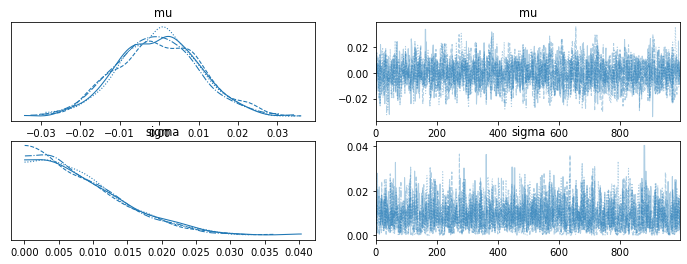

In [103]:
az.plot_trace(result, var_names=['mu', 'sigma']);